<a href="https://colab.research.google.com/github/andres-merino/MatematicaIII-05-N0051/blob/main/10Laboratorios/02-MovimientoGeometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/X5m8yDo.png" width="120">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#1957d1" size="7">|</font><br>
            <font color="#1957d1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="4">
                Matem&aacute;tica III &bull; Laboratorio 02
            </font></p>
            <p style="font-style: oblique;"><font color="#1957d1" size="3">
                Andr&eacute;s Merino &bull; Periodo 2026-01
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='1957d1'> Introducción </font>

Este laboratorio usa Python para analizar el movimiento de una partícula a lo largo de una curva y estudiar su geometría diferencial. Los resultados de aprendizaje de esta actividad son:

- **RdA 1.2:** Concepto de derivada en varias variables (aplicado a trayectorias).

Los paquetes necesarios son:

In [8]:
import sympy as sp               # Para cálculo simbólico
import numpy as np               # Para cálculo numérico
import matplotlib.pyplot as plt  # Para visualización

---
## <font color='1957d1'> Movimiento en el espacio </font>

Dada una trayectoria $\alpha: I \subseteq \mathbb{R} \to \mathbb{R}^n$, se definen:
- **Velocidad:** $v_\alpha(t) = \alpha'(t)$
- **Rapidez:** $\rho_\alpha(t) = \|\alpha'(t)\|$
- **Aceleración:** $a_\alpha(t) = \alpha''(t)$

En Python, se calcula la derivada de cada componente con `sp.diff(alpha, t)`.

**Ejemplo 1.** Analicemos el movimiento de la hélice $\alpha(t) = (\cos t,\, \sin t,\, t)$, $t \in [0, 4\pi]$.

In [9]:
t = sp.Symbol('t')

# Trayectoria: hélice
alpha = sp.Matrix([sp.cos(t), sp.sin(t), t])

# Velocidad, rapidez y aceleración
v = sp.diff(alpha, t)
rho = sp.simplify(sp.sqrt(v.dot(v)))
a = sp.diff(alpha, t, 2)

print('α(t) =', alpha.T)
print('v(t) =', v.T)
print('ρ(t) =', rho)
print('a(t) =', a.T)

α(t) = Matrix([[cos(t), sin(t), t]])
v(t) = Matrix([[-sin(t), cos(t), 1]])
ρ(t) = sqrt(2)
a(t) = Matrix([[-cos(t), -sin(t), 0]])


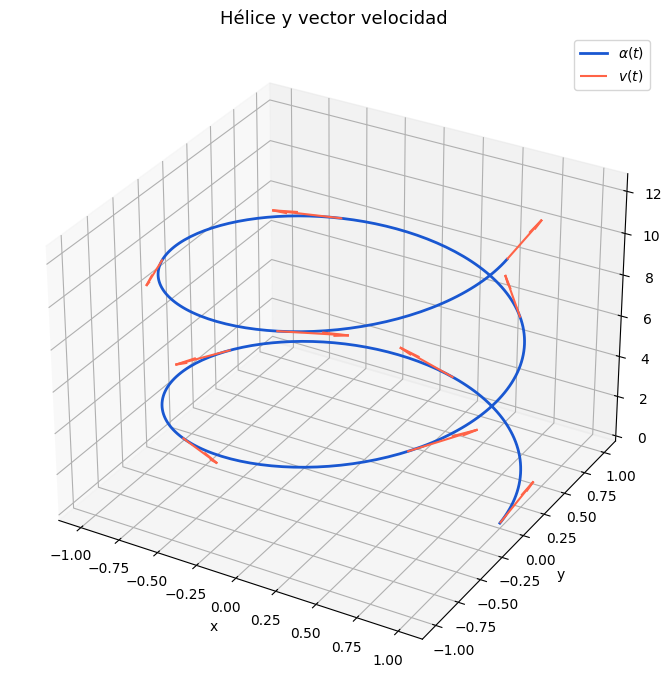

In [10]:
# Lambdificar para graficar
alpha_num = sp.lambdify(t, list(alpha), 'numpy')
v_num     = sp.lambdify(t, list(v),     'numpy')

# Curva
t_vals = np.linspace(0, 4*np.pi, 400)
x, y, z = alpha_num(t_vals)

# Puntos para dibujar vectores velocidad
t_pts = np.linspace(0, 4*np.pi, 10)
xp, yp, zp = alpha_num(t_pts)
vx, vy, vz = v_num(t_pts)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, color='#1957d1', linewidth=2, label=r'$\alpha(t)$')
ax.quiver(xp, yp, zp, vx, vy, vz, length=0.4, color='tomato', label=r'$v(t)$')
ax.set_title(r'Hélice y vector velocidad', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.legend()
plt.tight_layout()
plt.show()

---

<div style="background-color: #edf1f8; border-color: #1957d1; border-left: 5px solid #1957d1; padding: 0.5em;">
<strong>Ejercicio 1:</strong><br>
Para la trayectoria $\alpha(t) = (t,\, t^2,\, t^3)$, $t \in [0, 2]$:<br>
a) Calcula simbólicamente $v(t)$, $\rho(t)$ y $a(t)$.<br>
b) Grafica la curva con los vectores velocidad en 6 puntos.
</div>

---

In [11]:
# Ejercicio 1


---
## <font color='1957d1'> Vectores de Frenet </font>

Para una trayectoria $\alpha: I \to \mathbb{R}^3$ con $\alpha'(t) \neq 0$, el **triedro de Frenet** está formado por:
- **Tangente unitario:** $T(t) = \dfrac{v(t)}{\rho(t)}$
- **Normal principal:** $N(t) = \dfrac{T'(t)}{\|T'(t)\|}$
- **Binormal:** $B(t) = T(t) \times N(t)$

En Python se usan `sp.diff`, `sp.sqrt` y el método `.cross()` de `sp.Matrix`.

**Ejemplo 2.** Calculemos el triedro de Frenet de la hélice del Ejemplo 1.

In [12]:
# Vector tangente unitario
T = sp.trigsimp(v / rho)

# Vector normal principal
T_prima = sp.diff(T, t)
T_prima_norm = sp.trigsimp(sp.sqrt(T_prima.dot(T_prima)))
N = sp.trigsimp(T_prima / T_prima_norm)

# Vector binormal
B = sp.trigsimp(T.cross(N))

print('T(t) =', T.T)
print('N(t) =', N.T)
print('B(t) =', B.T)

T(t) = Matrix([[-sqrt(2)*sin(t)/2, sqrt(2)*cos(t)/2, sqrt(2)/2]])
N(t) = Matrix([[-cos(t), -sin(t), 0]])
B(t) = Matrix([[sqrt(2)*sin(t)/2, -sqrt(2)*cos(t)/2, sqrt(2)/2]])


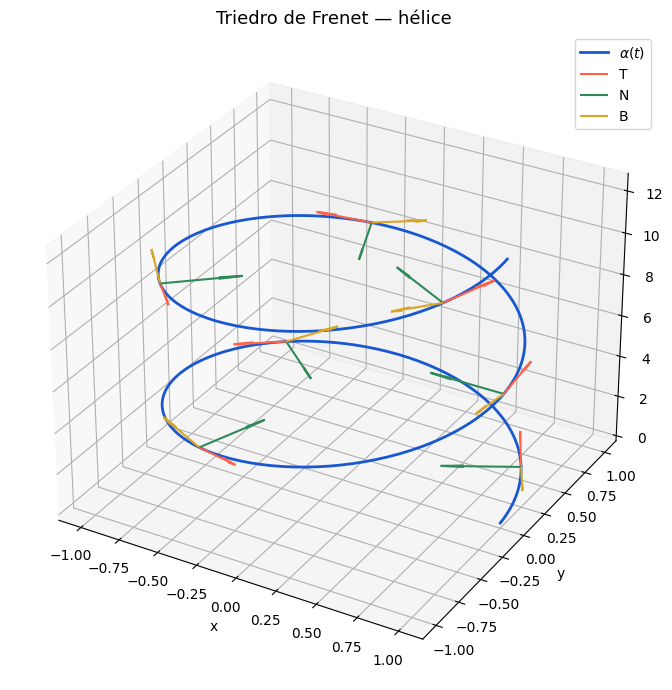

In [13]:
# Lambdificar vectores de Frenet
T_num = sp.lambdify(t, list(T), 'numpy')
N_num = sp.lambdify(t, list(N), 'numpy')
B_num = sp.lambdify(t, list(B), 'numpy')

# Puntos seleccionados para el triedro
t_pts = np.linspace(0.5, 4*np.pi - 0.5, 7)
xp, yp, zp = alpha_num(t_pts)

# np.ones_like garantiza que las componentes constantes también sean arrays
ones = np.ones_like(t_pts)
Tv = np.array([c * ones for c in T_num(t_pts)])
Nv = np.array([c * ones for c in N_num(t_pts)])
Bv = np.array([c * ones for c in B_num(t_pts)])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, color='#1957d1', linewidth=2, label=r'$\alpha(t)$')
ax.quiver(xp, yp, zp, Tv[0], Tv[1], Tv[2], length=0.45, color='tomato',    label='T')
ax.quiver(xp, yp, zp, Nv[0], Nv[1], Nv[2], length=0.45, color='seagreen',  label='N')
ax.quiver(xp, yp, zp, Bv[0], Bv[1], Bv[2], length=0.45, color='goldenrod', label='B')
ax.set_title('Triedro de Frenet — hélice', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.legend()
plt.tight_layout()
plt.show()

---

<div style="background-color: #edf1f8; border-color: #1957d1; border-left: 5px solid #1957d1; padding: 0.5em;">
<strong>Ejercicio 2:</strong><br>
Para la trayectoria $\alpha(t) = (2\cos t,\, 2\sin t,\, \cos(2t))$, $t \in [0, 2\pi]$:<br>
a) Calcula simbólicamente $T(t)$, $N(t)$ y $B(t)$.<br>
b) Visualiza el triedro de Frenet sobre la curva en al menos 6 puntos.
</div>

---

In [14]:
# Ejercicio 2


---
## <font color='1957d1'> Longitud de arco y curvatura </font>

Para una trayectoria $\alpha: [a,b] \to \mathbb{R}^n$:
- **Longitud de arco:** $\ell(C) = \displaystyle\int_a^b \rho(t)\, dt$
- **Curvatura:** $\kappa(t) = \dfrac{\|T'(t)\|}{\rho(t)}$

En Python se usa `sp.integrate` para la longitud y la fórmula directa para $\kappa$.

**Ejemplo 3.** Calculemos la longitud y la curvatura de la hélice en $[0, 4\pi]$.

In [15]:
# Longitud de arco en [0, 4π]
L = sp.integrate(rho, (t, 0, 4*sp.pi))
print('Longitud de arco:', L)

# Curvatura
kappa = sp.trigsimp(T_prima_norm / rho)
print('κ(t) =', kappa)

Longitud de arco: 4*sqrt(2)*pi
κ(t) = 1/2


La curvatura constante confirma que la hélice se dobla uniformemente a lo largo de toda la curva.

---

<div style="background-color: #edf1f8; border-color: #1957d1; border-left: 5px solid #1957d1; padding: 0.5em;">
<strong>Ejercicio 3:</strong><br>
Para la trayectoria $\alpha(t) = (t,\, t^2,\, t^3)$:<br>
a) Calcula la longitud de arco en $[0, 1]$.<br>
b) Calcula $\kappa(t)$ y evalúa en $t = 0$.<br>
c) ¿Qué indica el valor de $\kappa(0)$?
</div>

---

In [16]:
# Ejercicio 3
